#📄**Algoritmo de Dijkstra**(Caminos más cortos en un  grafo)


##En esta actividad, aprenderás a calcular el camino más corto en un grafo utilizando el algoritmo de Dijkstra. Utilizaremos un grafo ponderado dirigido, representado mediante una matriz de adyacencia, que contiene los pesos entre los nodos.

### Objetivos:
- Definir el concepto de ruta más corta en un grafo.
- Calcular el camino mínimo desde un vértice al resto de los vértices.
- Determinar si existe un camino entre cualquier par de vértices.
- Resolver problemas prácticos utilizando grafos.


[texto del enlace](https://)

In [81]:
%%html
<iframe width="560" height="315"
src="https://www.youtube.com/embed/4I7W5WUQQQI?start=973"
frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture"
allowfullscreen>
</iframe


## EJEMPLO DEL PDF gui-10.pdf link:
https://drive.google.com/file/d/1jJ4f0zLebUNNWtUbv6fPc1EZ36ke543g/view?usp=drive_link


In [27]:
import pandas as pd

# Cargar datos del archivo CSV
matriz = pd.read_csv("matriz_adyacencia.csv", header=None)

# Mostrar la matriz completa como DataFrame (como en el .csv)
print("Matriz de Adyacencia (Original):")
matriz
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Mostrar la matriz
matriz



Matriz de Adyacencia (Original):


,0,1,2,3,4,5,6
0,-1,10,18,-1,-1,-1,-1
1,-1,-1,6,-1,3,-1,-1
2,-1,-1,-1,-1,20,-1,-1
3,-1,-1,2,-1,1,-1,2
4,-1,-1,-1,8,-1,-1,10
5,-1,-1,-1,-1,-1,-1,-1
6,-1,-1,-1,-1,-1,5,-1


In [31]:
import heapq

def dijkstra(matriz, inicio):
    n = len(matriz)
    distancias = [np.inf] * n
    distancias[inicio] = 0
    visitados = set()
    heap = [(0, inicio)]

    while heap:
        distancia_actual, nodo_actual = heapq.heappop(heap)
        if nodo_actual in visitados:
            continue
        visitados.add(nodo_actual)

        for vecino in range(n):
            peso = matriz.iloc[nodo_actual, vecino]
            if peso != np.inf:
                distancia = distancia_actual + peso
                if distancia < distancias[vecino]:
                    distancias[vecino] = distancia
                    heapq.heappush(heap, (distancia, vecino))

    return distancias



In [14]:
# Ejemplo: Desde el vértice 1 (índice 0 en Python)
origen = 0
distancias = dijkstra(matriz, origen)

print(f"Distancias mínimas desde el vértice {origen + 1}:")
for i, d in enumerate(distancias):
    print(f"Vértice {i + 1}: {d if d != np.inf else 'No existe camino'}")


Distancias mínimas desde el vértice 1:
Vértice 1: 0
Vértice 2: 10.0
Vértice 3: 16.0
Vértice 4: 21.0
Vértice 5: 13.0
Vértice 6: 28.0
Vértice 7: 23.0


In [32]:
print("Existencia de camino entre pares de vértices:")
n = len(matriz)
for i in range(n):
    dist = dijkstra(matriz, i)
    for j in range(n):
        if dist[j] != np.inf:
            print(f"Existe un camino de {i + 1} a {j + 1} con costo {dist[j]}")
        else:
            print(f"No existe camino de {i + 1} a {j + 1}")


Existencia de camino entre pares de vértices:
Existe un camino de 1 a 1 con costo -7
Existe un camino de 1 a 2 con costo -7
Existe un camino de 1 a 3 con costo -7
Existe un camino de 1 a 4 con costo -6
Existe un camino de 1 a 5 con costo -7
Existe un camino de 1 a 6 con costo -7
Existe un camino de 1 a 7 con costo -6
Existe un camino de 2 a 1 con costo -7
Existe un camino de 2 a 2 con costo -7
Existe un camino de 2 a 3 con costo -7
Existe un camino de 2 a 4 con costo -6
Existe un camino de 2 a 5 con costo -7
Existe un camino de 2 a 6 con costo -7
Existe un camino de 2 a 7 con costo -6
Existe un camino de 3 a 1 con costo -6
Existe un camino de 3 a 2 con costo -6
Existe un camino de 3 a 3 con costo -6
Existe un camino de 3 a 4 con costo -6
Existe un camino de 3 a 5 con costo -6
Existe un camino de 3 a 6 con costo -6
Existe un camino de 3 a 7 con costo -6
Existe un camino de 4 a 1 con costo -7
Existe un camino de 4 a 2 con costo -7
Existe un camino de 4 a 3 con costo -7
Existe un camino d

In [33]:
# 1. Camino mínimo de nodo 1 a nodo 6
origen = 0
destino = 5
distancias = dijkstra(matriz, origen)
print(f"Distancia mínima de 1 a 6: {distancias[destino]}")

# 2. Nodo más lejano desde el nodo 4
origen = 3
distancias = dijkstra(matriz, origen)
max_dist = max(distancias)
nodo_lejano = distancias.index(max_dist) + 1
print(f"Nodo más lejano desde el nodo 4: {nodo_lejano} con distancia {max_dist}")

# 3. Existencia de camino entre nodo 3 y nodo 7
origen = 2
destino = 6
distancias = dijkstra(matriz, origen)
if distancias[destino] != np.inf:
    print(f"Existe un camino de 3 a 7 con costo {distancias[destino]}")
else:
    print("No existe camino de 3 a 7")


Distancia mínima de 1 a 6: -7
Nodo más lejano desde el nodo 4: 6 con distancia -6
Existe un camino de 3 a 7 con costo -6


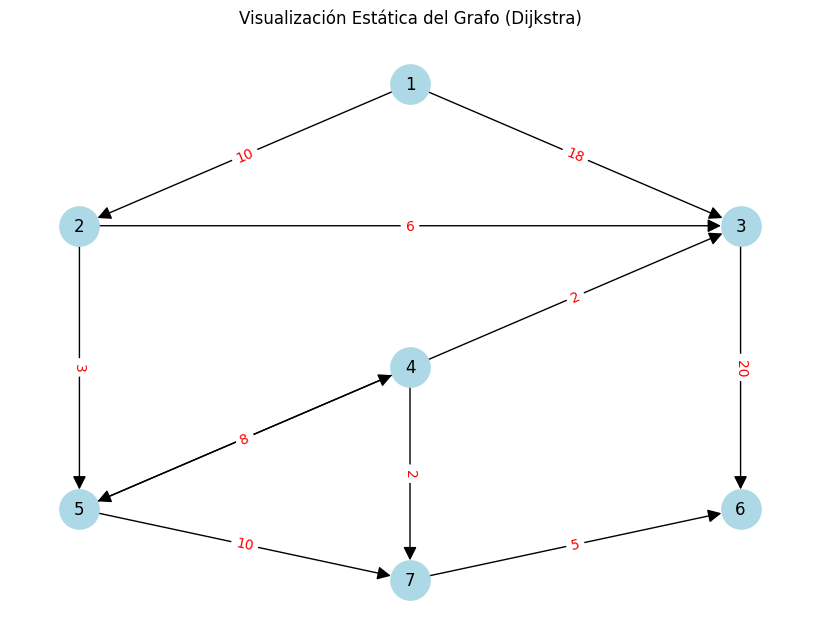

In [34]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear el grafo dirigido
G = nx.DiGraph()

# Añadir las aristas con sus pesos
edges = [
    (1, 2, 10), (1, 3, 18),
    (2, 3, 6), (2, 5, 3),
    (3, 6, 20),
    (4, 3, 2), (4, 5, 8), (4, 7, 2),
    (5, 4, 8), (5, 7, 10),
    (7, 6, 5)
]
G.add_weighted_edges_from(edges)

# Definir posiciones manuales (parecido al grafo de la imagen)
pos = {
    1: (0, 2),    # Nodo 1 arriba
    2: (-1.5, 1), # Nodo 2 a la izquierda
    3: (1.5, 1),  # Nodo 3 a la derecha
    4: (0, 0),    # Nodo 4 en el centro
    5: (-1.5, -1),# Nodo 5 abajo izquierda
    6: (1.5, -1), # Nodo 6 abajo derecha
    7: (0, -1.5)  # Nodo 7 abajo
}

# Dibujar el grafo
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=800, arrowsize=20)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_color='red', font_size=10)
plt.title("Visualización Estática del Grafo (Dijkstra)")
plt.axis('off')
plt.show()


In [36]:
def dijkstra(matriz, origen):
    n = len(matriz)
    visitados = [False] * n
    distancia = [np.inf] * n
    distancia[origen] = 0

    for _ in range(n):
        # Elegir el nodo no visitado con menor distancia
        min_dist = np.inf
        nodo = -1
        for i in range(n):
            if not visitados[i] and distancia[i] < min_dist:
                min_dist = distancia[i]
                nodo = i

        if nodo == -1:
            break

        visitados[nodo] = True

        # Actualizar distancias
        for i in range(n):
            if matriz[nodo][i] != np.inf and distancia[nodo] + matriz[nodo][i] < distancia[i]:
                distancia[i] = distancia[nodo] + matriz[nodo][i]

    return distancia

In [29]:
resultado = dijkstra(matriz.to_numpy(), 0)
print("Distancia mínima desde el vértice 0 a los demás vértices:")
print(resultado)

Distancia mínima desde el vértice 0 a los demás vértices:
[np.int64(-8), np.int64(-8), np.int64(-8), np.int64(-9), np.int64(-8), np.int64(-9), np.int64(-9)]


In [30]:
def existe_camino(matriz, origen, destino):
    distancias = dijkstra(matriz.to_numpy(), origen)
    return distancias[destino] != np.inf

print("¿Existe un camino de 0 a 6?:", existe_camino(matriz, 0, 6))
print("¿Existe un camino de 5 a 0?:", existe_camino(matriz, 5, 0))

¿Existe un camino de 0 a 6?: True
¿Existe un camino de 5 a 0?: True


In [37]:
# 📌 Proyecto: Camino más corto con el Algoritmo de Dijkstra

from IPython.display import display, Markdown
display(Markdown("## 🔍 Algoritmo de Dijkstra - Grafo Dirigido y Ponderado\n\nEsta notebook permite construir un grafo dirigido con pesos no negativos y aplicar el algoritmo de Dijkstra para hallar el camino más corto desde un nodo origen."))

display(Markdown("### 🧾 Basado en la Guía 10\n- Las aristas deben tener un peso **no negativo**.\n- El grafo debe ser **dirigido** y **ponderado**.\n"))


## 🔍 Algoritmo de Dijkstra - Grafo Dirigido y Ponderado

Esta notebook permite construir un grafo dirigido con pesos no negativos y aplicar el algoritmo de Dijkstra para hallar el camino más corto desde un nodo origen.

### 🧾 Basado en la Guía 10
- Las aristas deben tener un peso **no negativo**.
- El grafo debe ser **dirigido** y **ponderado**.


#**⏫⏫⏫⏫⏫⏫⏫⏫⏫TAREA⏫⏫⏫⏫⏫⏫⏫⏫⏫**
#**⏫⏫⏫⏫⏫⏫⏫⏫⏫TAREA⏫⏫⏫⏫⏫⏫⏫⏫⏫**

#📌Solicitar número de nodos



¿Cuántos nodos tendrá tu grafo?: 9


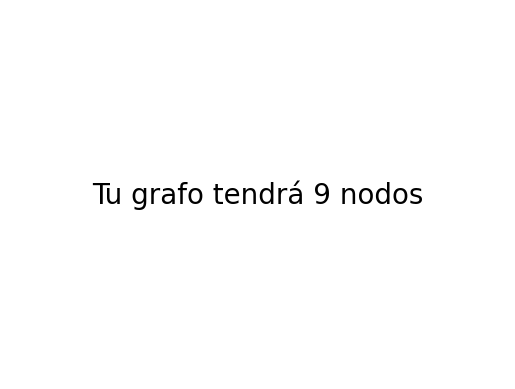

In [72]:
import matplotlib.pyplot as plt

# Pedir número de nodos
n = int(input("¿Cuántos nodos tendrá tu grafo?: "))

# Mostrar mensaje en imagen
fig, ax = plt.subplots()
ax.text(0.5, 0.5, f"Tu grafo tendrá {n} nodos", fontsize=20, ha='center', va='center')
ax.axis('off')
plt.show()


#📌Seleccionar opción de entrada de pesos

In [73]:
# Mostrar opciones
print("¿Cómo deseas ingresar los pesos del grafo?")
print("1. Generar pesos aleatorios")
print("2. Ingresar los pesos manualmente")

opcion = int(input("Selecciona una opción (1 o 2): "))
matriz = np.full((n, n), -1)  # Inicializar con -1 como indica la guía

if opcion == 1:
    for i in range(n):
        for j in range(n):
            if i != j:
                # 50% de probabilidad de que exista una arista
                if np.random.rand() > 0.5:
                    matriz[i][j] = np.random.randint(1, 20)
elif opcion == 2:
    for i in range(n):
        for j in range(n):
            if i != j:
                peso = input(f"Ingresa el peso de la arista de {i} a {j} (o presiona Enter si no hay conexión): ")
                if peso.strip() != "":
                    peso = int(peso)
                    if peso >= 0:
                        matriz[i][j] = peso
                    else:
                        print("⚠️ El peso debe ser no negativo. Se omitirá esta conexión.")
else:
    print("⚠️ Opción inválida. Ejecuta la celda nuevamente.")

# Convertir a DataFrame para visualización
df = pd.DataFrame(matriz, columns=[f"Nodo {i}" for i in range(n)], index=[f"Nodo {i}" for i in range(n)])

print("📊 Matriz de pesos del grafo (con -1 donde no hay conexión):")
df


¿Cómo deseas ingresar los pesos del grafo?
1. Generar pesos aleatorios
2. Ingresar los pesos manualmente
Selecciona una opción (1 o 2): 1
📊 Matriz de pesos del grafo (con -1 donde no hay conexión):


,Nodo 0,Nodo 1,Nodo 2,Nodo 3,Nodo 4,Nodo 5,Nodo 6,Nodo 7,Nodo 8
Nodo 0,-1,-1,3,11,-1,-1,15,-1,3
Nodo 1,11,-1,9,19,-1,-1,2,-1,-1
Nodo 2,-1,3,-1,-1,-1,-1,-1,4,3
Nodo 3,8,11,-1,-1,-1,16,-1,13,-1
Nodo 4,-1,8,6,5,-1,14,-1,-1,-1
Nodo 5,-1,16,17,11,-1,-1,-1,-1,-1
Nodo 6,14,-1,4,4,4,9,-1,-1,-1
Nodo 7,-1,-1,6,-1,-1,5,-1,-1,-1
Nodo 8,15,1,4,6,-1,-1,-1,-1,-1


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


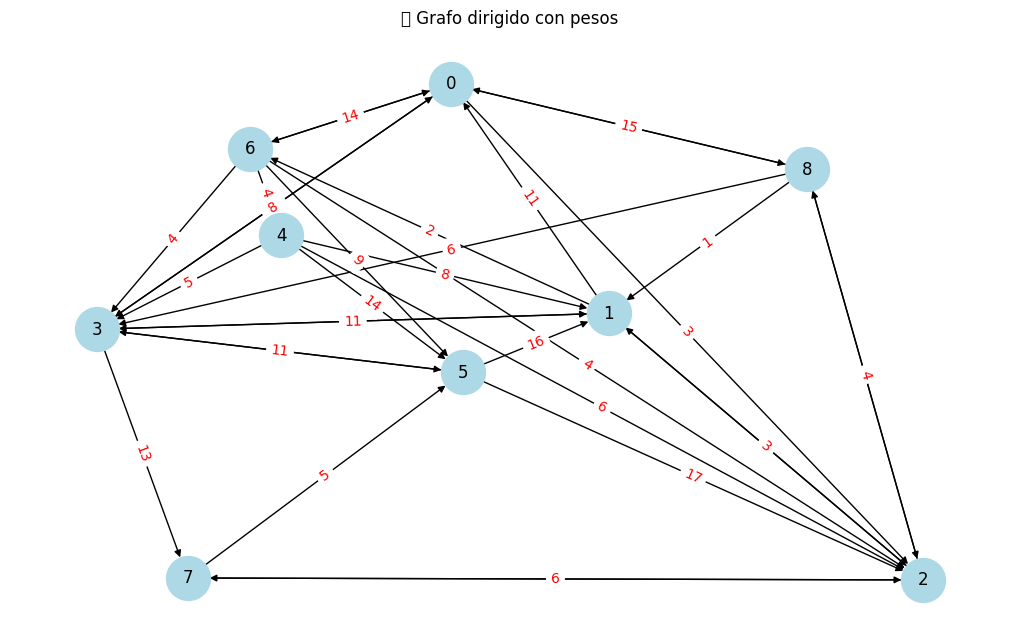

In [74]:
# Crear grafo dirigido
G = nx.DiGraph()

# Agregar nodos
G.add_nodes_from(range(n))

# Agregar aristas con pesos
for i in range(n):
    for j in range(n):
        if matriz[i][j] != -1:
            G.add_edge(i, j, weight=matriz[i][j])

# Posiciones automáticas para los nodos
pos = nx.spring_layout(G, seed=42)  # Puedes cambiar el layout si deseas

# Dibujar nodos y aristas
plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1000, arrows=True, font_size=12)
# Dibujar etiquetas de pesos
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_color='red')
plt.title("🔗 Grafo dirigido con pesos")
plt.show()


#📌Implementación del algoritmo de Dijkstra y ejecución desde nodo origen

In [75]:
def dijkstra(matriz, origen):
    n = len(matriz)
    visitados = [False] * n
    distancia = [np.inf] * n
    distancia[origen] = 0

    for _ in range(n):
        # Seleccionar el nodo no visitado con menor distancia
        min_dist = np.inf
        nodo_actual = -1
        for i in range(n):
            if not visitados[i] and distancia[i] < min_dist:
                min_dist = distancia[i]
                nodo_actual = i

        if nodo_actual == -1:
            break

        visitados[nodo_actual] = True

        # Actualizar las distancias de los vecinos del nodo actual
        for vecino in range(n):
            peso = matriz[nodo_actual][vecino]
            if peso != -1 and not visitados[vecino]:
                nueva_distancia = distancia[nodo_actual] + peso
                if nueva_distancia < distancia[vecino]:
                    distancia[vecino] = nueva_distancia

    return distancia

# Pedir nodo de origen
origen = int(input(f"Selecciona el nodo de origen (0 a {n-1}): "))

# Ejecutar algoritmo
distancias = dijkstra(matriz, origen)

# Mostrar resultados
print(f"\n📍 Distancias mínimas desde el nodo {origen}:\n")
for i, d in enumerate(distancias):
    if d == np.inf:
        print(f"🟥 No hay camino de {origen} a {i}")
    else:
        print(f"✅ Distancia de {origen} a {i}: {d}")


Selecciona el nodo de origen (0 a 8): 6

📍 Distancias mínimas desde el nodo 6:

✅ Distancia de 6 a 0: 12
✅ Distancia de 6 a 1: 7
✅ Distancia de 6 a 2: 4
✅ Distancia de 6 a 3: 4
✅ Distancia de 6 a 4: 4
✅ Distancia de 6 a 5: 9
✅ Distancia de 6 a 6: 0
✅ Distancia de 6 a 7: 8
✅ Distancia de 6 a 8: 7


#✅Ruta más corta entre dos nudos con camino reconstruido

In [76]:
def dijkstra_camino(matriz, origen):
    n = len(matriz)
    distancia = [np.inf] * n
    visitados = [False] * n
    anterior = [None] * n
    distancia[origen] = 0

    for _ in range(n):
        min_dist = np.inf
        nodo_actual = -1
        for i in range(n):
            if not visitados[i] and distancia[i] < min_dist:
                min_dist = distancia[i]
                nodo_actual = i

        if nodo_actual == -1:
            break

        visitados[nodo_actual] = True

        for vecino in range(n):
            peso = matriz[nodo_actual][vecino]
            if peso != -1 and not visitados[vecino]:
                nueva_dist = distancia[nodo_actual] + peso
                if nueva_dist < distancia[vecino]:
                    distancia[vecino] = nueva_dist
                    anterior[vecino] = nodo_actual

    return distancia, anterior

# Mostrar nodos disponibles
print(f"Nodos disponibles: {[i for i in range(n)]}")
origen = int(input("Selecciona el nodo inicial: "))

# Mostrar nodos restantes
restantes = [i for i in range(n) if i != origen]
print(f"Nodos destino disponibles: {restantes}")
destino = int(input("Selecciona el nodo final: "))

# Ejecutar algoritmo y reconstruir camino
distancias, anteriores = dijkstra_camino(matriz, origen)

# Reconstruir el camino
camino = []
nodo = destino
while nodo is not None:
    camino.insert(0, nodo)
    nodo = anteriores[nodo]

# Mostrar resultados
if distancias[destino] == np.inf:
    print(f"🟥 No hay camino de {origen} a {destino}")
else:
    print(f"\n✅ Ruta más corta de {origen} a {destino}: {' → '.join(map(str, camino))}")
    print(f"💰 Costo mínimo: {distancias[destino]}")


Nodos disponibles: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Selecciona el nodo inicial: 2
Nodos destino disponibles: [0, 1, 3, 4, 5, 6, 7, 8]
Selecciona el nodo final: 8

✅ Ruta más corta de 2 a 8: 2 → 8
💰 Costo mínimo: 3


#📌Graficar el camino más corto resaltado

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


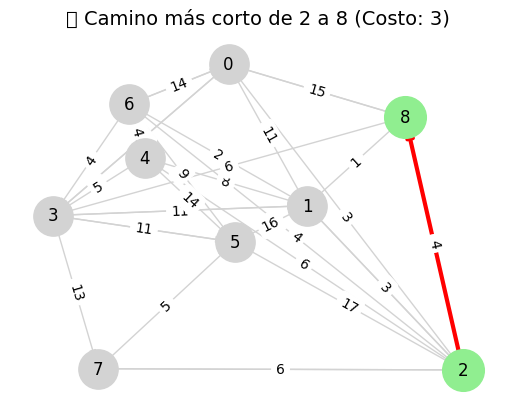

In [77]:
# Crear grafo dirigido
G = nx.DiGraph()

# Agregar nodos
G.add_nodes_from(range(n))

# Agregar aristas con pesos
for i in range(n):
    for j in range(n):
        if matriz[i][j] != -1:
            G.add_edge(i, j, weight=matriz[i][j])

# Posición de nodos (puedes cambiar por otro layout si deseas)
pos = nx.spring_layout(G, seed=42)

# Extraer aristas del camino más corto
camino_aristas = [(camino[i], camino[i+1]) for i in range(len(camino)-1)]

# Dibujar todos los nodos y aristas en gris
nx.draw_networkx_edges(G, pos, edge_color='lightgray')
nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=800)
nx.draw_networkx_labels(G, pos, font_size=12)

# Dibujar aristas del camino más corto en rojo
nx.draw_networkx_edges(G, pos, edgelist=camino_aristas, edge_color='red', width=3)

# Dibujar nodos del camino más corto en verde
nx.draw_networkx_nodes(G, pos, nodelist=camino, node_color='lightgreen', node_size=900)

# Mostrar etiquetas de pesos
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black')

plt.title(f"📍 Camino más corto de {origen} a {destino} (Costo: {distancias[destino]})", fontsize=14)
plt.axis('off')
plt.show()


#📌Generar imagen de la tabla con ruta resaltada


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


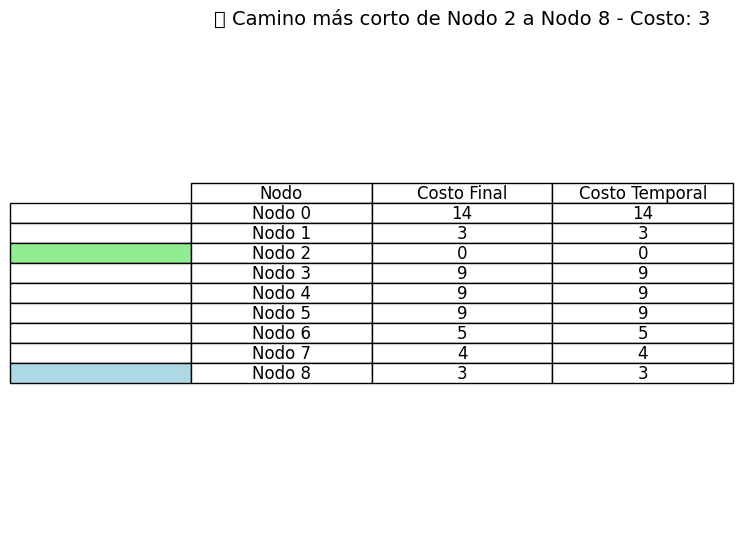

📌 El nodo vértice 2 tiene como camino más corto hacia el nodo vértice 8 un costo total de 3.
📎 Esto se debe a que tomó el siguiente camino según los pesos de las aristas:
🛣️  (2→8)(3)


In [78]:
import matplotlib.pyplot as plt

# Preparar datos para mostrar en imagen
column_labels = ["Nodo", "Costo Final", "Costo Temporal"]
cell_text = []

for i in range(n):
    final = distancias[i] if distancias[i] != np.inf else "-"
    temporal = final
    cell_text.append([f"Nodo {i}", final, temporal])

# Colores para resaltar
row_colors = []
for i in range(n):
    if i == origen:
        row_colors.append("lightgreen")  # Nodo origen
    elif i == destino:
        row_colors.append("lightblue")   # Nodo destino
    elif i in camino:
        row_colors.append("mistyrose")   # Parte del camino
    else:
        row_colors.append("white")

# Crear figura con tabla
fig, ax = plt.subplots(figsize=(7, n * 0.5 + 2))
ax.axis("off")
tabla_img = ax.table(cellText=cell_text,
                     colLabels=column_labels,
                     cellLoc='center',
                     loc='center',
                     rowColours=row_colors)
tabla_img.auto_set_font_size(False)
tabla_img.set_fontsize(12)
tabla_img.scale(1, 1.2)

# Título
plt.title(f"📋 Camino más corto de Nodo {origen} a Nodo {destino} - Costo: {distancias[destino]}", fontsize=14)
plt.show()

# Explicación tipo reporte
if distancias[destino] == np.inf:
    print(f"🟥 No hay camino posible desde el nodo {origen} hasta el nodo {destino}.")
else:
    detalle_ruta = []
    for i in range(len(camino)-1):
        u = camino[i]
        v = camino[i+1]
        peso = matriz[u][v]
        detalle_ruta.append(f"({u}→{v})({peso})")

    ruta_str = " ➤ ".join(detalle_ruta)
    print(f"📌 El nodo vértice {origen} tiene como camino más corto hacia el nodo vértice {destino} un costo total de {distancias[destino]}.")
    print(f"📎 Esto se debe a que tomó el siguiente camino según los pesos de las aristas:")
    print(f"🛣️  {ruta_str}")
